# Feature Engineering and Serviceability Analysis

## Objective

The objective of this notebook is to investigate the relationship between borrower origination characteristics and future financial stress outcomes.

The analysis will:

- Merge origination and loan performance datasets
- Assess data quality
- Study relationships between borrower features and stress outcomes
- Identify significant serviceability indicators
- Design a Borrower Serviceability Score (BSS)
- Generate a master dataset for predictive modelling

This notebook forms the exploratory feature engineering stage of the project.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: /Users/dhairyas87/Documents/Projects/explainable-credit-risk-management/xai-credit-risk-freddie-mac


## Import Required Libraries

The following libraries are used for:

- Data loading and manipulation
- Numerical analysis
- Visualization
- Loading project-specific modules

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_origination

## Load Origination Dataset

The origination dataset contains borrower and loan characteristics available at the time of mortgage origination.

Examples include:

- Credit Score
- Debt-to-Income Ratio (DTI)
- Loan-to-Value Ratio (LTV)
- Interest Rate
- Original Loan Balance
- Occupancy Status
- Loan Purpose

These variables will be investigated as potential predictors of borrower stress.

In [3]:
orig_df = load_origination(
    "../data/raw/historical_data_2018Q1.txt"
)

print(orig_df.shape)

(296816, 32)


## Load Loan Performance Dataset

The loan performance dataset was generated during the target creation phase.

It contains:

- Maximum delinquency observed
- Modification history
- Assistance history
- BSSI (Borrower Serviceability Stress Index)
- Stress Flag

Each row represents one unique loan.

In [4]:
loan_perf = pd.read_parquet(
    "../data/processed/loan_perf_2018Q1.parquet"
)

print(loan_perf.shape)

(296816, 7)


## Validate Dataset Consistency

Before merging datasets, we verify that both datasets contain the same number of unique loans.

This ensures that:

- No loans are missing
- No duplicate records exist
- The merge operation will produce a valid master dataset

In [5]:
print(
    "Origination Loans:",
    orig_df["loan_identifier"].nunique()
)

print(
    "Performance Loans:",
    loan_perf["loan_identifier"].nunique()
)

Origination Loans: 296816
Performance Loans: 296816


## Merge Origination and Performance Datasets

The origination dataset contains borrower characteristics, while the performance dataset contains future borrower outcomes.

Combining these datasets allows us to study which origination characteristics are associated with future financial stress.

In [6]:
master_df = orig_df.merge(
    loan_perf,
    on="loan_identifier",
    how="inner"
)

print(master_df.shape)

(296816, 38)


In [7]:
master_df.head()

,credit_score,first_payment_date,first_time_homebuyer_indicator,maturity_date,msa,mortgage_insurance_pct,num_units,occupancy_status,cltv,dti,...,property_valuation_method,interest_only_indicator,mortgage_insurance_type,vantagescore_4,max_delinquency,ever_ra,ever_modified,ever_assistance,bssi,stress_flag
0,785,201803,N,204802,49180.0,0,1,I,80,34,...,NaN,7,N,7,0,False,False,False,0,0
1,761,201804,N,203803,NaN,0,1,P,57,43,...,NaN,7,N,7,1,False,False,False,1,1
2,726,201804,N,203803,19430.0,0,1,P,46,15,...,NaN,7,N,7,0,False,False,False,0,0
3,678,201805,Y,204804,39100.0,0,1,P,72,39,...,NaN,7,N,7,0,False,False,False,0,0
4,798,201803,N,204802,NaN,0,1,S,66,17,...,NaN,7,N,7,0,False,False,False,0,0


# Data Quality Assessment

Freddie Mac datasets use placeholder values such as:

- 999
- 9999

to represent missing information.

Before performing analysis, these values must be identified and converted to proper missing values.

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": [
        (master_df["credit_score"] == 9999).sum(),
        (master_df["dti"] == 999).sum(),
        (master_df["ltv"] == 999).sum(),
        (master_df["cltv"] == 999).sum()
    ]
},
index=[
    "credit_score",
    "dti",
    "ltv",
    "cltv"
])

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(master_df)
    * 100
)

missing_summary

,missing_count,missing_pct
credit_score,28,0.009433
dti,5258,1.771468
ltv,14,0.004717
cltv,17,0.005727


### Observation

The percentage of missing values is relatively small.

The Debt-to-Income Ratio (DTI) exhibits the highest proportion of missing values, while Credit Score, LTV, and CLTV contain only a negligible number of missing observations.

These placeholder values will now be converted into proper missing values.

In [12]:
master_df["credit_score"] = (
    master_df["credit_score"]
    .replace(9999, np.nan)
)

master_df["dti"] = (
    master_df["dti"]
    .replace(999, np.nan)
)

master_df["ltv"] = (
    master_df["ltv"]
    .replace(999, np.nan)
)

master_df["cltv"] = (
    master_df["cltv"]
    .replace(999, np.nan)
)

In [13]:
master_df[
    [
        "credit_score",
        "dti",
        "ltv",
        "cltv"
    ]
].isna().sum()

credit_score      28
dti             5258
ltv               14
cltv              17
dtype: int64

# Credit Score and Financial Stress Analysis

## Research Question

Do borrowers with lower credit scores experience higher levels of future financial stress?

Credit score is one of the most widely used indicators of borrower creditworthiness. Lower credit scores may indicate a greater likelihood of repayment difficulties and future financial stress.

In this section, we compare credit score distributions between healthy and stressed borrowers.

In [24]:
master_df.groupby(
    "stress_flag"
)["credit_score"].describe()

,count,mean,std,min,25%,50%,75%,max
stress_flag,,,,,,,,
0,254008.0,749.532960,44.440790,479.0,719.0,757.0,786.0,840.0
1,42780.0,722.361594,49.151469,427.0,687.0,722.0,761.0,850.0


### Average Credit Score by Stress Status

The following analysis compares the average credit score between:

- Healthy borrowers (stress_flag = 0)
- Financially stressed borrowers (stress_flag = 1)

A significant difference would indicate that credit score is a useful predictor of future borrower stress.

In [25]:
credit_summary = (
    master_df.groupby("stress_flag")["credit_score"]
    .mean()
    .reset_index()
)

credit_summary

,stress_flag,credit_score
0,0,749.532960
1,1,722.361594


<Figure size 800x500 with 0 Axes>

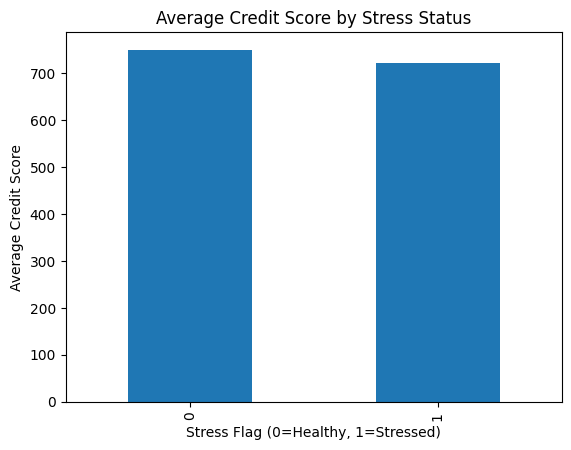

In [26]:
plt.figure(figsize=(8,5))

credit_summary.plot(
    x="stress_flag",
    y="credit_score",
    kind="bar",
    legend=False
)

plt.title("Average Credit Score by Stress Status")
plt.xlabel("Stress Flag (0=Healthy, 1=Stressed)")
plt.ylabel("Average Credit Score")

plt.show()

### Interpretation

The analysis indicates a substantial difference in average credit scores between healthy and stressed borrowers.

Key observations:

- Healthy borrowers exhibit higher average credit scores.
- Financially stressed borrowers exhibit lower average credit scores.
- The difference suggests that credit score is strongly associated with future borrower stress.

### Finding

Credit Score appears to be one of the strongest predictors of future borrower serviceability and will be included in the proposed Borrower Serviceability Score framework.

# Debt-to-Income Ratio (DTI) and Financial Stress Analysis

## Research Question

Does a higher debt burden contribute to future borrower stress?

The Debt-to-Income Ratio (DTI) measures the proportion of borrower income committed to debt obligations.

Higher DTI values indicate greater financial burden and potentially reduced repayment flexibility.

In [27]:
master_df.groupby(
    "stress_flag"
)["dti"].describe()

,count,mean,std,min,25%,50%,75%,max
stress_flag,,,,,,,,
0,250097.0,35.316185,9.549966,1.0,28.0,36.0,43.0,50.0
1,41461.0,37.965220,8.896679,1.0,32.0,40.0,45.0,50.0


In [28]:
dti_summary = (
    master_df.groupby("stress_flag")["dti"]
    .mean()
    .reset_index()
)

dti_summary

,stress_flag,dti
0,0,35.316185
1,1,37.965220


<Figure size 800x500 with 0 Axes>

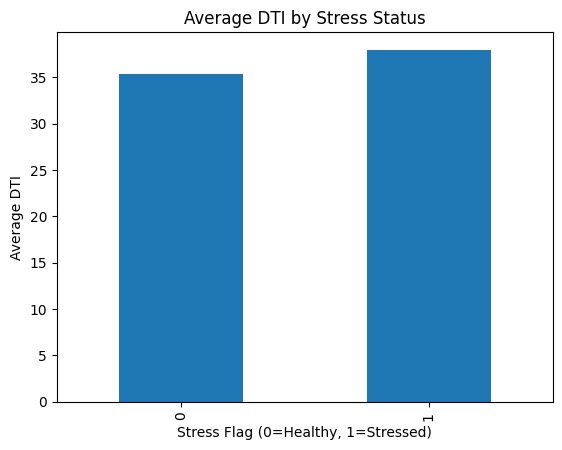

In [29]:
plt.figure(figsize=(8,5))

dti_summary.plot(
    x="stress_flag",
    y="dti",
    kind="bar",
    legend=False
)

plt.title("Average DTI by Stress Status")
plt.xlabel("Stress Flag (0=Healthy, 1=Stressed)")
plt.ylabel("Average DTI")

plt.show()

### Interpretation

Borrowers experiencing financial stress exhibit higher Debt-to-Income ratios compared to healthy borrowers.

This indicates that:

- Higher debt burden reduces financial flexibility.
- Borrowers with greater debt commitments are more vulnerable to financial stress.
- DTI is an important indicator of borrower serviceability.

### Finding

Debt-to-Income Ratio will be considered as a key component of the Borrower Serviceability Score.

# Comparison of Credit Score and DTI Across BSSI Levels

The previous analysis compared healthy and stressed borrowers.

We now investigate how borrower characteristics evolve across increasing levels of financial stress represented by the Borrower Serviceability Stress Index (BSSI).

Expected relationship:

- Credit Score decreases as stress increases.
- DTI increases as stress increases.

In [30]:
master_df.groupby("bssi")[
    [
        "credit_score",
        "dti"
    ]
].mean()

,credit_score,dti
bssi,,
0,749.532960,35.316185
1,725.620282,37.459537
2,712.459691,39.564228
3,707.854545,36.675325


In [31]:
bssi_analysis = (
    master_df.groupby("bssi")[
        [
            "credit_score",
            "dti"
        ]
    ]
    .mean()
)

bssi_analysis

,credit_score,dti
bssi,,
0,749.532960,35.316185
1,725.620282,37.459537
2,712.459691,39.564228
3,707.854545,36.675325


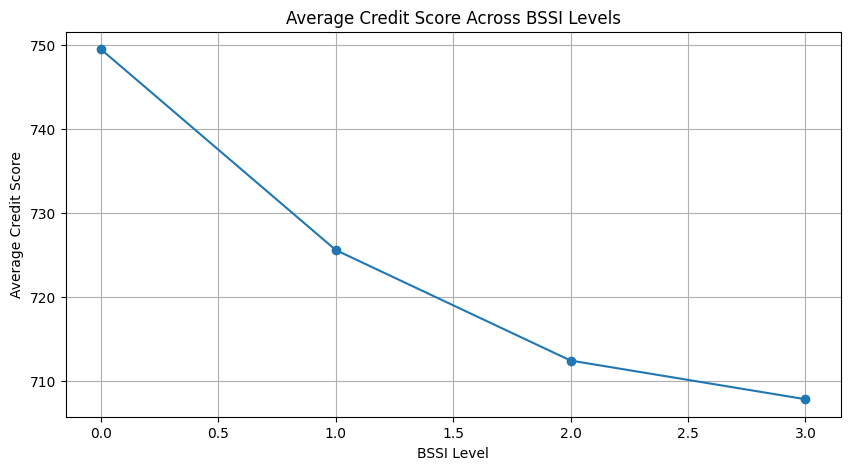

In [32]:
plt.figure(figsize=(10,5))

bssi_analysis["credit_score"].plot(
    marker="o"
)

plt.title("Average Credit Score Across BSSI Levels")
plt.xlabel("BSSI Level")
plt.ylabel("Average Credit Score")

plt.grid(True)
plt.show()

### Observation

A clear downward trend is observed in average credit scores as BSSI levels increase.

This provides strong evidence that borrowers experiencing greater financial stress generally originate with lower credit scores.

The relationship supports the inclusion of Credit Score as a primary serviceability indicator.

# Interest Rate and Financial Stress Analysis

## Research Question

Do borrowers with higher interest rates experience greater financial stress?

Interest rate directly influences monthly mortgage payments. Higher interest rates increase repayment obligations and may reduce borrower serviceability.

This section investigates whether interest rate is associated with future financial stress.

In [33]:
master_df.groupby(
    "stress_flag"
)["interest_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
stress_flag,,,,,,,,
0,254031.0,4.369545,0.445162,2.5,4.125,4.375,4.625,6.625
1,42785.0,4.492719,0.470308,0.0,4.125,4.500,4.830,6.625


In [34]:
interest_summary = (
    master_df.groupby("stress_flag")["interest_rate"]
    .mean()
    .reset_index()
)

interest_summary

,stress_flag,interest_rate
0,0,4.369545
1,1,4.492719


<Figure size 800x500 with 0 Axes>

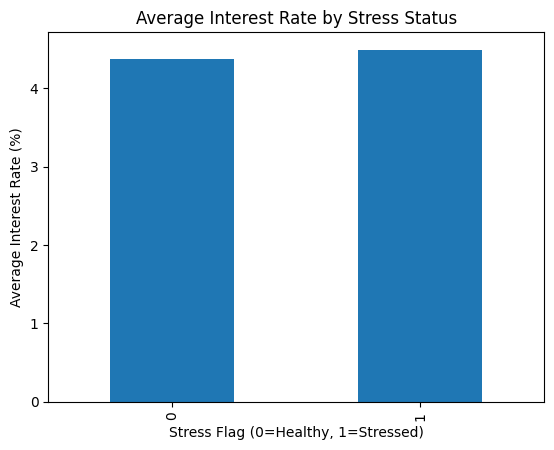

In [35]:
plt.figure(figsize=(8,5))

interest_summary.plot(
    x="stress_flag",
    y="interest_rate",
    kind="bar",
    legend=False
)

plt.title("Average Interest Rate by Stress Status")
plt.xlabel("Stress Flag (0=Healthy, 1=Stressed)")
plt.ylabel("Average Interest Rate (%)")

plt.show()

### Interpretation

The analysis demonstrates that stressed borrowers were generally associated with higher origination interest rates.

A higher interest rate increases monthly repayment obligations and reduces affordability.

### Finding

Interest Rate exhibits a meaningful relationship with borrower stress and will be considered in the proposed Borrower Serviceability Score framework.

# Loan-to-Value Ratio (LTV) and Financial Stress Analysis

## Research Question

Does higher leverage contribute to future financial stress?

The Loan-to-Value Ratio (LTV) represents the proportion of the property's value financed through debt.

Higher LTV values imply:

- Lower borrower equity
- Higher leverage
- Greater vulnerability to adverse market conditions

In [37]:
master_df.groupby(
    "stress_flag"
)["ltv"].describe()

,count,mean,std,min,25%,50%,75%,max
stress_flag,,,,,,,,
0,254019.0,74.434294,17.307469,5.0,66.0,80.0,85.0,201.0
1,42783.0,75.560106,16.999419,5.0,68.0,80.0,90.0,230.0


In [38]:
ltv_summary = (
    master_df.groupby("stress_flag")["ltv"]
    .mean()
    .reset_index()
)

ltv_summary

,stress_flag,ltv
0,0,74.434294
1,1,75.560106


<Figure size 800x500 with 0 Axes>

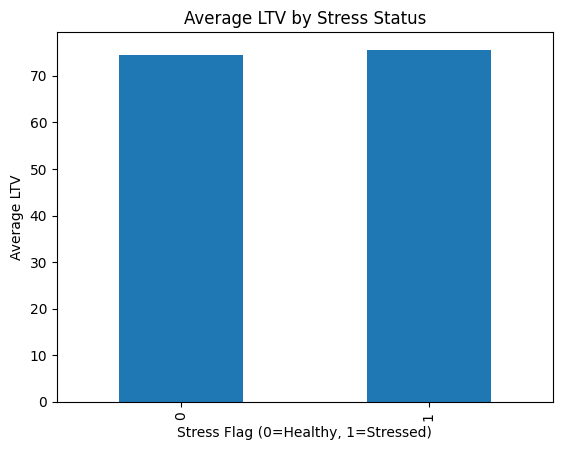

In [39]:
plt.figure(figsize=(8,5))

ltv_summary.plot(
    x="stress_flag",
    y="ltv",
    kind="bar",
    legend=False
)

plt.title("Average LTV by Stress Status")
plt.xlabel("Stress Flag (0=Healthy, 1=Stressed)")
plt.ylabel("Average LTV")

plt.show()

### Interpretation

Although stressed borrowers exhibit slightly higher LTV ratios, the difference is less pronounced than for Credit Score, DTI, or Interest Rate.

This suggests that LTV contributes to borrower stress but may not be a primary serviceability indicator.

### Finding

LTV will be retained as a supporting feature within the Serviceability Score framework.

# Number of Borrowers and Financial Stress Analysis

## Research Question

Does having multiple borrowers improve borrower serviceability?

Loans with multiple borrowers may benefit from:

- Multiple income streams
- Greater repayment flexibility
- Reduced vulnerability to income shocks

This analysis evaluates whether borrower count influences financial stress outcomes.

In [41]:
pd.crosstab(
    master_df["num_borrowers"],
    master_df["stress_flag"],
    normalize="columns"
) * 100

stress_flag,0,1
num_borrowers,,
1,52.3381,63.143625
2,47.6619,36.856375


In [42]:
borrower_analysis = (
    pd.crosstab(
        master_df["num_borrowers"],
        master_df["stress_flag"],
        normalize="columns"
    ) * 100
)

borrower_analysis

stress_flag,0,1
num_borrowers,,
1,52.3381,63.143625
2,47.6619,36.856375


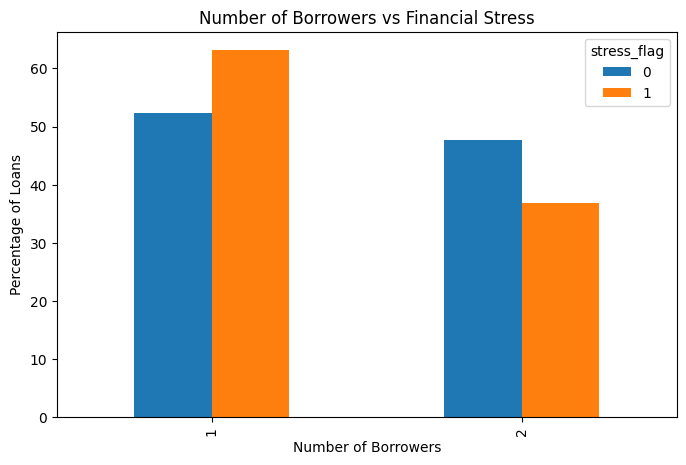

In [43]:
borrower_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Borrowers vs Financial Stress")
plt.xlabel("Number of Borrowers")
plt.ylabel("Percentage of Loans")

plt.show()

### Interpretation

Single-borrower loans are more prevalent among financially stressed borrowers.

Conversely, healthy borrowers exhibit a greater proportion of loans with multiple borrowers.

This suggests that income diversification contributes positively to borrower serviceability.

### Finding

Number of Borrowers will be incorporated into the proposed Serviceability Score framework.

# Analysis Across BSSI Levels

The previous sections compared healthy and stressed borrowers.

To better understand the progression of financial stress, we now investigate how key borrower characteristics evolve across increasing BSSI levels.

This analysis provides evidence for selecting variables used in the Borrower Serviceability Score.

In [44]:
bssi_feature_analysis = (
    master_df.groupby("bssi")[
        [
            "credit_score",
            "dti",
            "ltv",
            "interest_rate"
        ]
    ]
    .mean()
)

bssi_feature_analysis

,credit_score,dti,ltv,interest_rate
bssi,,,,
0,749.532960,35.316185,74.434294,4.369545
1,725.620282,37.459537,74.586783,4.470150
2,712.459691,39.564228,78.435252,4.559275
3,707.854545,36.675325,85.066667,4.720473


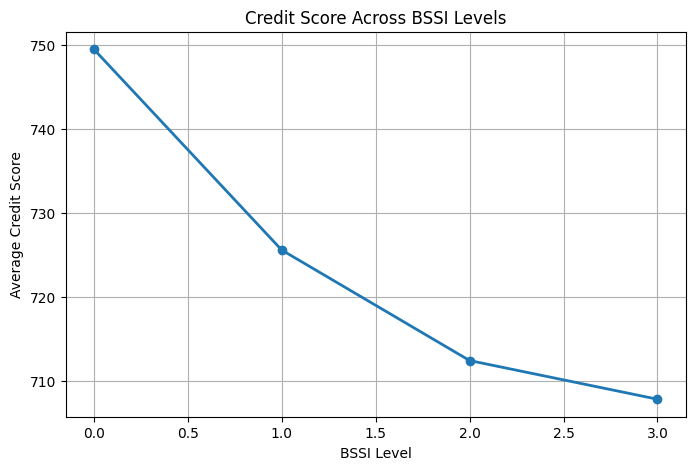

In [45]:
plt.figure(figsize=(8,5))

bssi_feature_analysis["credit_score"].plot(
    marker="o",
    linewidth=2
)

plt.title("Credit Score Across BSSI Levels")
plt.xlabel("BSSI Level")
plt.ylabel("Average Credit Score")

plt.grid(True)

plt.show()

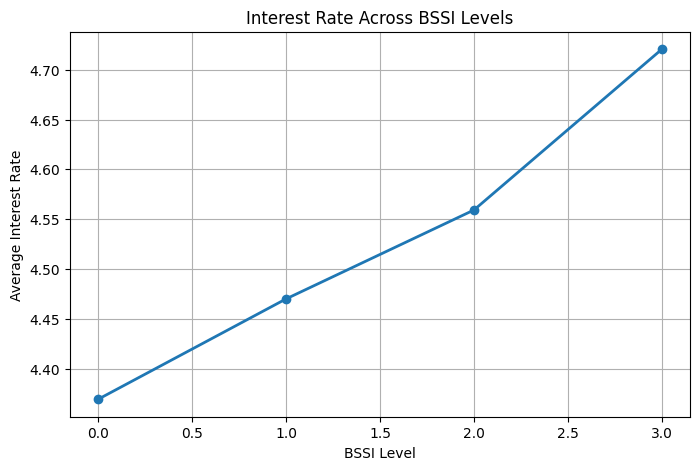

In [46]:
plt.figure(figsize=(8,5))

bssi_feature_analysis["interest_rate"].plot(
    marker="o",
    linewidth=2
)

plt.title("Interest Rate Across BSSI Levels")
plt.xlabel("BSSI Level")
plt.ylabel("Average Interest Rate")

plt.grid(True)

plt.show()

## Key Findings

The analysis reveals several important relationships:

1. Credit Score decreases consistently as borrower stress increases.
2. Interest Rate increases consistently as borrower stress increases.
3. DTI increases with borrower stress and reflects repayment burden.
4. Multiple borrowers appear to improve financial resilience.
5. LTV contributes to borrower stress but exhibits weaker predictive power.

These findings provide a strong empirical basis for the construction of the proposed Borrower Serviceability Score.

# Borrower Serviceability Score (BSS)

## Motivation

The previous analysis identified several borrower characteristics that exhibit meaningful relationships with future financial stress.

Key findings include:

- Lower Credit Scores are associated with higher borrower stress.
- Higher Debt-to-Income Ratios (DTI) are associated with higher borrower stress.
- Higher Interest Rates are associated with higher borrower stress.
- Single-borrower loans are more likely to experience financial stress.
- Higher LTV values contribute to borrower stress.

Based on these observations, a Borrower Serviceability Score (BSS) is proposed to estimate borrower repayment capacity at origination.

The objective of the score is to provide a single interpretable measure of borrower serviceability.

## Proposed Serviceability Components

The Borrower Serviceability Score incorporates the following dimensions:

| Component | Rationale |
|------------|------------|
| Credit Score | Creditworthiness |
| DTI | Debt Burden |
| Interest Rate | Repayment Burden |
| Number of Borrowers | Income Diversification |
| LTV | Borrower Leverage |

The score is designed such that:

- Higher scores indicate better serviceability.
- Lower scores indicate increased borrower risk.

In [47]:
bss_df = master_df.copy()

## Feature Normalization

The selected variables operate on different numerical scales.

Examples:

- Credit Score ranges approximately from 300 to 850.
- DTI ranges from 0 to 50.
- Interest Rate ranges from 2% to 7%.

To combine these variables into a single score, min-max normalization is applied.

In [48]:
# Higher is better

bss_df["credit_score_norm"] = (
    (bss_df["credit_score"] - bss_df["credit_score"].min())
    /
    (bss_df["credit_score"].max() - bss_df["credit_score"].min())
)

# Lower is better

bss_df["dti_norm"] = 1 - (
    (bss_df["dti"] - bss_df["dti"].min())
    /
    (bss_df["dti"].max() - bss_df["dti"].min())
)

# Lower is better

bss_df["interest_rate_norm"] = 1 - (
    (bss_df["interest_rate"] - bss_df["interest_rate"].min())
    /
    (bss_df["interest_rate"].max() - bss_df["interest_rate"].min())
)

# Lower is better

bss_df["ltv_norm"] = 1 - (
    (bss_df["ltv"] - bss_df["ltv"].min())
    /
    (bss_df["ltv"].max() - bss_df["ltv"].min())
)

# Higher is better

bss_df["num_borrowers_norm"] = (
    (bss_df["num_borrowers"] - bss_df["num_borrowers"].min())
    /
    (bss_df["num_borrowers"].max() - bss_df["num_borrowers"].min())
)

## Weight Assignment

Based on the exploratory analysis:

| Feature | Weight |
|----------|----------|
| Credit Score | 40% |
| DTI | 25% |
| Interest Rate | 20% |
| Number Borrowers | 10% |
| LTV | 5% |

The weights reflect the relative strength of the observed relationships between borrower characteristics and financial stress outcomes.

In [49]:
bss_df["bss"] = (

    0.40 * bss_df["credit_score_norm"]

    + 0.25 * bss_df["dti_norm"]

    + 0.20 * bss_df["interest_rate_norm"]

    + 0.10 * bss_df["num_borrowers_norm"]

    + 0.05 * bss_df["ltv_norm"]

) * 100

In [50]:
bss_df["bss"].describe()

count    291517.000000
mean         52.320520
std           9.136919
min          25.224107
25%          45.625688
50%          51.896131
75%          58.704872
max          84.668493
Name: bss, dtype: float64

## BSS Distribution

The Borrower Serviceability Score represents the overall repayment capacity of a borrower at origination.

Higher values indicate:

- Stronger credit profile
- Lower debt burden
- Better affordability
- Greater resilience

Lower values indicate reduced borrower serviceability.

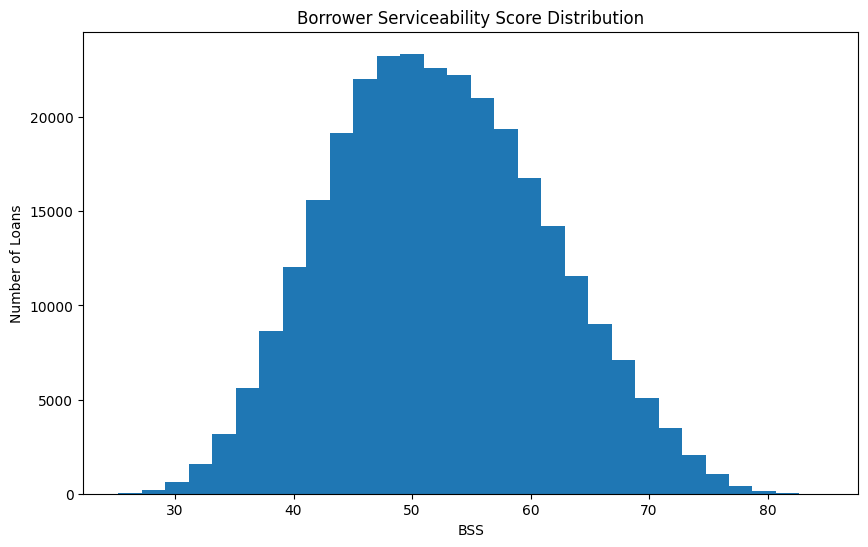

In [51]:
plt.figure(figsize=(10,6))

plt.hist(
    bss_df["bss"],
    bins=30
)

plt.title(
    "Borrower Serviceability Score Distribution"
)

plt.xlabel("BSS")

plt.ylabel("Number of Loans")

plt.show()

## Validation of Serviceability Score

A useful Serviceability Score should exhibit a relationship with future borrower stress.

The following analysis compares average BSS across BSSI levels.

In [52]:
bss_df.groupby(
    "bssi"
)["bss"].mean()

bssi
0    53.076864
1    48.543367
2    45.357763
3    44.402847
Name: bss, dtype: float64

In [53]:
bss_validation = (
    bss_df.groupby("bssi")["bss"]
    .mean()
)

bss_validation

bssi
0    53.076864
1    48.543367
2    45.357763
3    44.402847
Name: bss, dtype: float64

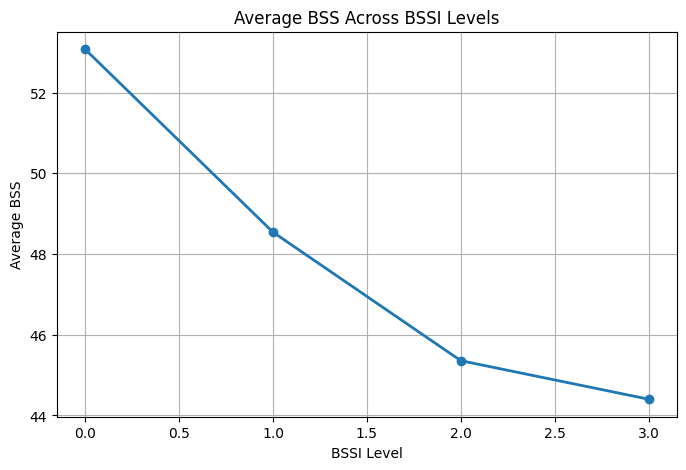

In [54]:
plt.figure(figsize=(8,5))

bss_validation.plot(
    marker="o",
    linewidth=2
)

plt.title(
    "Average BSS Across BSSI Levels"
)

plt.xlabel(
    "BSSI Level"
)

plt.ylabel(
    "Average BSS"
)

plt.grid(True)

plt.show()

## Validation of Borrower Serviceability Score

The proposed Borrower Serviceability Score demonstrates a clear inverse relationship with future borrower stress.

Average BSS decreases consistently across increasing BSSI levels:

| BSSI | Average BSS |
|--------|------------|
| 0 | 53.08 |
| 1 | 48.54 |
| 2 | 45.36 |
| 3 | 44.40 |

This indicates that borrowers with lower serviceability scores at origination subsequently experienced higher levels of financial stress.

The observed monotonic trend provides preliminary validation of the proposed serviceability framework.

# Serviceability Bucket Analysis

## Motivation

While the Borrower Serviceability Score (BSS) provides a continuous measure of borrower repayment capacity, business users and risk analysts often prefer interpretable risk segments.

To improve interpretability, borrowers are grouped into five serviceability categories:

- Very Low Serviceability
- Low Serviceability
- Medium Serviceability
- High Serviceability
- Very High Serviceability

These categories facilitate portfolio analysis and risk communication.

In [57]:
bss_df["bss_bucket"] = pd.qcut(
    bss_df["bss"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

bss_df["bss_bucket"].value_counts().sort_index()

bss_bucket
Very Low     58305
Low          58302
Medium       58303
High         58303
Very High    58304
Name: count, dtype: int64

## Stress Rate by Serviceability Category

The following analysis evaluates whether borrowers with lower serviceability scores are more likely to experience financial stress.

A successful serviceability score should demonstrate decreasing stress rates as serviceability improves.

In [58]:
stress_by_bucket = (
    pd.crosstab(
        bss_df["bss_bucket"],
        bss_df["stress_flag"],
        normalize="index"
    ) * 100
)

stress_by_bucket

stress_flag,0,1
bss_bucket,,
Very Low,74.072550,25.927450
Low,82.842784,17.157216
Medium,86.966365,13.033635
High,90.714028,9.285972
Very High,94.302278,5.697722


In [59]:
stress_rate = (
    stress_by_bucket[1]
    .reset_index()
)

stress_rate.columns = [
    "bss_bucket",
    "stress_rate"
]

stress_rate

,bss_bucket,stress_rate
0,Very Low,25.927450
1,Low,17.157216
2,Medium,13.033635
3,High,9.285972
4,Very High,5.697722


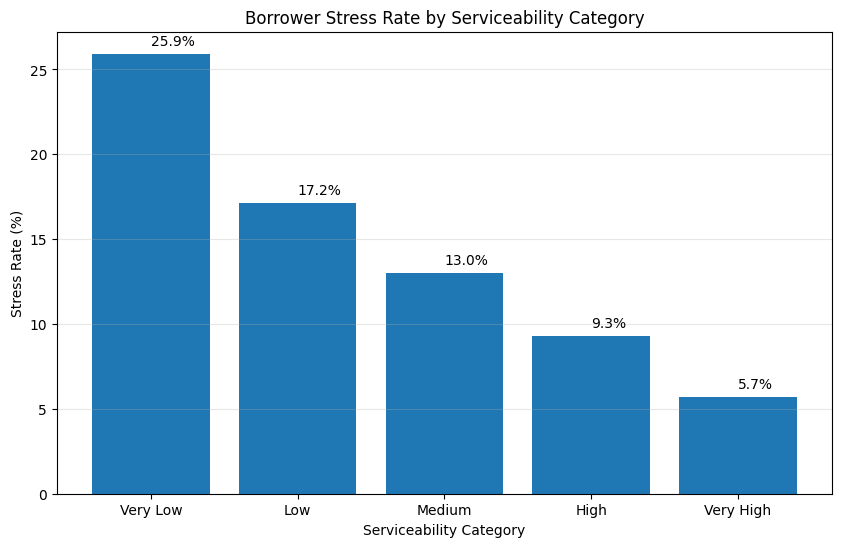

In [60]:
plt.figure(figsize=(10,6))

plt.bar(
    stress_rate["bss_bucket"],
    stress_rate["stress_rate"]
)

plt.title(
    "Borrower Stress Rate by Serviceability Category"
)

plt.xlabel(
    "Serviceability Category"
)

plt.ylabel(
    "Stress Rate (%)"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for idx, value in enumerate(
    stress_rate["stress_rate"]
):
    plt.text(
        idx,
        value + 0.5,
        f"{value:.1f}%"
    )

plt.show()

## Interpretation

A strong inverse relationship is observed between borrower serviceability and future financial stress.

Key observations:

- Borrowers within the Very Low Serviceability category exhibit a stress rate of approximately 26%.
- Borrowers within the Very High Serviceability category exhibit a stress rate of approximately 6%.
- Stress rates decrease consistently as serviceability improves.

The results indicate that borrowers with poor serviceability at origination are substantially more likely to experience future repayment difficulties.

This provides strong empirical support for the proposed Borrower Serviceability Score framework.

## Key Research Finding

Borrowers classified as Very Low Serviceability were approximately 4.5 times more likely to experience financial stress than borrowers classified as Very High Serviceability.

Stress Rate Ratio:

25.93 / 5.70 ≈ 4.55

This demonstrates that the proposed Borrower Serviceability Score successfully captures meaningful differences in borrower risk profiles.

# Final Feature Set

The final dataset contains:

### Origination Features

- Credit Score
- DTI
- LTV
- CLTV
- Interest Rate
- Original UPB
- Property Characteristics
- Occupancy Status
- Loan Purpose
- Borrower Characteristics

### Target Variables

- BSSI
- Stress Flag

### Engineered Features

- Borrower Serviceability Score (BSS)
- Serviceability Bucket (BSS Bucket)

This dataset will be used in subsequent predictive modelling and explainable AI experiments.

In [61]:
bss_df[
    [
        "loan_identifier",
        "bss",
        "bss_bucket",
        "bssi",
        "stress_flag"
    ]
].head()

,loan_identifier,bss,bss_bucket,bssi,stress_flag
0,F18Q10000001,49.500970,Medium,0,0
1,F18Q10000002,46.169609,Low,1,1
2,F18Q10000003,68.144792,Very High,0,0
3,F18Q10000004,47.764241,Low,0,0
4,F18Q10000005,73.865808,Very High,0,0


# Save Master Dataset

The master dataset combines:

- Origination characteristics
- Financial stress outcomes
- Engineered serviceability features

This dataset will serve as the primary input for machine learning model development.

In [62]:
bss_df.to_parquet(
    "../data/processed/master_dataset_2018Q1.parquet",
    index=False
)

print(
    "master_dataset_2018Q1.parquet saved successfully."
)

master_dataset_2018Q1.parquet saved successfully.


In [63]:
saved_df = pd.read_parquet(
    "../data/processed/master_dataset_2018Q1.parquet"
)

print(saved_df.shape)

(296816, 45)
